In [17]:
import pandas as pd
from scipy.optimize import linear_sum_assignment
from visualization import (
    accuracy_metrics_errorbar_plot_missing_samples,
    heatmap_plot_accuracy_metrics_uneven_pseudobulk,
    super_plot_heatmaps_pseudobulk,
    heatmap_plot_accuracy_metrics_pseudobulk_vs_sc,
    super_plot_heatmaps_uneven_pseudobulk,
    heatmap_plot_accuracy_metrics_pseudobulk_rd0
)

from accuracy_functions import (
    loop_accuracy_calculations,
    calculate_accuracy_metrics_pseudobulk,
    accuracy_metrics_hysys_heatmap_vireo_algorithm,
)
from analysis_shared_functions import (
    parse_heatmap_matrix_vireo,
    parse_heatmap_matrix_hysys,
    create_pseudobulk_submatrix_vireo,
    inferred_matches_pseudobulk_vireo
)

In [2]:
tools = ["CrosscheckFingerprints", "HYSYS", "Vireo", "NGSCheckmate"]
ncells_list = [10000, 50000, 100000, 500000]
read_depths = [0, 1, 10, 20, 30, 40]
datasets = ["hgsoc", "high_grade_glioma", "low_grade_glioma"]

In [3]:
DATA_PATH = "../../data/output_data/" # Path to the directory containing the data files
FIGURES_PATH = "../../data/figures/" # Path to the directory where the figures will be saved

# Missing samples

No results found for 0 samples removed and iteration 2. Skipping accuracy calculations for this number of samples removed.
No results found for 0 samples removed and iteration 3. Skipping accuracy calculations for this number of samples removed.
No results found for 0 samples removed and iteration 4. Skipping accuracy calculations for this number of samples removed.
No results found for 0 samples removed and iteration 5. Skipping accuracy calculations for this number of samples removed.
No results found for 0 samples removed and iteration 2. Skipping accuracy calculations for this number of samples removed.
No results found for 0 samples removed and iteration 3. Skipping accuracy calculations for this number of samples removed.
No results found for 0 samples removed and iteration 4. Skipping accuracy calculations for this number of samples removed.
No results found for 0 samples removed and iteration 5. Skipping accuracy calculations for this number of samples removed.
No results found

/Users/lathouwe/miniconda3/envs/analysis/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lathouwe/miniconda3/envs/analysis/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


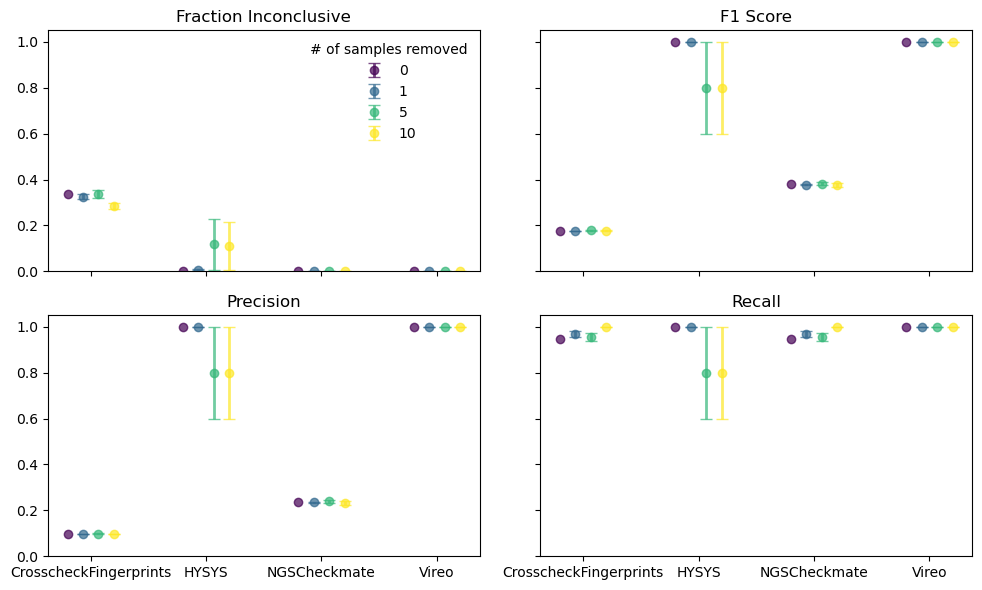

In [8]:
# Grid of 4 errorbar plots for different accuracy metrics (fraction inconclusive, f1, precision, recall)
# Each subplot shows the accuracy metric for different tools as a function of the number of samples removed, 
# with error bars representing the standard error across iterations.
# Note that the data for this plot only exists for the parameters used here
accuracy_metrics_errorbar_plot_missing_samples(
    DATA_PATH=DATA_PATH, 
    experiment="missing_samples", 
    dataset="high_grade_glioma", 
    ncells=500000, 
    rd=0, 
    n_samples_removed=[0, 1, 5, 10], 
    n_iterations=5, 
    FIGURES_PATH=FIGURES_PATH, 
    save_fig=False
)

# Double samples

No results found for 0 samples removed and iteration 2. Skipping accuracy calculations for this number of samples removed.
No results found for 0 samples removed and iteration 3. Skipping accuracy calculations for this number of samples removed.
No results found for 0 samples removed and iteration 4. Skipping accuracy calculations for this number of samples removed.
No results found for 0 samples removed and iteration 5. Skipping accuracy calculations for this number of samples removed.
No results found for 0 samples removed and iteration 2. Skipping accuracy calculations for this number of samples removed.
No results found for 0 samples removed and iteration 3. Skipping accuracy calculations for this number of samples removed.
No results found for 0 samples removed and iteration 4. Skipping accuracy calculations for this number of samples removed.
No results found for 0 samples removed and iteration 5. Skipping accuracy calculations for this number of samples removed.
No results found

/Users/lathouwe/miniconda3/envs/analysis/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


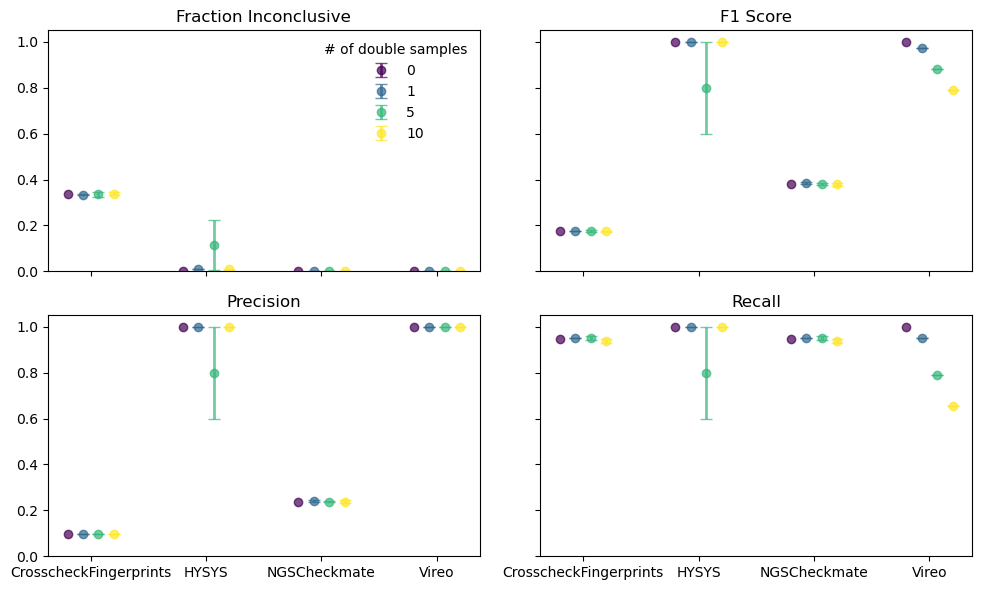

In [9]:
# Grid of 4 errorbar plots for different accuracy metrics (fraction inconclusive, f1, precision, recall)
# Each subplot shows the accuracy metric for different tools as a function of the number of double samples, 
# with error bars representing the standard error across iterations.
# Note that the data for this plot only exists for the parameters used here
accuracy_metrics_errorbar_plot_missing_samples(
    DATA_PATH=DATA_PATH, 
    experiment="double_samples", 
    dataset="high_grade_glioma", 
    ncells=500000, 
    rd=0, 
    n_samples_removed=[0, 1, 5, 10], 
    n_iterations=5, 
    FIGURES_PATH=FIGURES_PATH, 
    save_fig=False
)

In [62]:
folder = "double_samples_"
n = 10
i = 5
dataset = "high_grade_glioma"
ncells = 500000
rd = 0
experiment = "double_samples"

In [63]:
matrix = parse_heatmap_matrix_vireo(
    DATA_PATH + f"{folder}{n}/it_{i}/", True, dataset, ncells, rd
)
_, hysys_matrix = parse_heatmap_matrix_hysys(
    DATA_PATH + f"{folder}{n}/it_{i}/", True, dataset, ncells, rd
)
n_samples_double = n if experiment == "double_samples" else 0
inferred_matches = create_pseudobulk_submatrix_vireo(matrix, hysys_matrix, experiment, n_samples_double)

In [74]:
hysys_matrix.shape

(48, 48)

In [64]:
all_samples = list(set(hysys_matrix.index))
samples_1 = [sample for sample in all_samples if sample.endswith("_1")]
samples_2 = [sample for sample in all_samples if sample.endswith("_2")]

In [65]:
len(all_samples), len(samples_1), len(samples_2)

(48, 19, 19)

In [66]:
samples_3 = [sample for sample in all_samples if sample.endswith("_3")]
matrix_filtered = matrix.loc[
    [idx for idx in matrix.index if idx in samples_1],
    [col for col in matrix.columns if col in samples_2 or col in samples_3],
]

In [67]:
matrix_filtered.shape

(19, 29)

In [68]:
idx0, idx1 = linear_sum_assignment(matrix_filtered.values, False)
matrix_reordered = pd.DataFrame(
    matrix_filtered.iloc[idx0, idx1],
    index=matrix_filtered.index[idx0],
    columns=matrix_filtered.columns[idx1],
)

In [69]:
matrix_reordered.columns

Index(['GSM7305260_pseudobulk_GSM7305260_ncells_500000_2',
       'GSM7305261_pseudobulk_GSM7305261_ncells_500000_2',
       'GSM7305262_pseudobulk_GSM7305262_ncells_500000_2',
       'GSM7305263_pseudobulk_GSM7305263_ncells_500000_2',
       'GSM7305264_pseudobulk_GSM7305264_ncells_500000_2',
       'GSM7305265_pseudobulk_GSM7305265_ncells_500000_2',
       'GSM7305266_pseudobulk_GSM7305266_ncells_500000_2',
       'GSM7305267_pseudobulk_GSM7305267_ncells_500000_2',
       'GSM7305268_pseudobulk_GSM7305268_ncells_500000_2',
       'GSM7305269_pseudobulk_GSM7305269_ncells_500000_2',
       'GSM7305270_pseudobulk_GSM7305270_ncells_500000_2',
       'GSM7305271_pseudobulk_GSM7305271_ncells_500000_2',
       'GSM7305272_pseudobulk_GSM7305272_ncells_500000_2',
       'GSM7305273_pseudobulk_GSM7305273_ncells_500000_2',
       'GSM7305274_pseudobulk_GSM7305274_ncells_500000_2',
       'GSM7305275_pseudobulk_GSM7305275_ncells_500000_2',
       'GSM7305276_pseudobulk_GSM7305276_ncells_500000_2

# Uneven pseudobulk sizes

## Accuracy plots

In [ ]:
# Note that the data used in this section only exists for the parameters used here
# Loop through the different pseudobulk sizes for the second pseudobulk and calculate accuracy metrics for each tool, dataset, and read depth.
full_df = pd.DataFrame()

for ncells_2 in ncells_list:

    df = loop_accuracy_calculations(
        DATA_PATH=DATA_PATH + f"uneven_pseudobulk_sizes/ncells_{ncells_2}/",
        experiment="uneven_pseudobulk",
        tools=tools,
        datasets=["high_grade_glioma"],
        ncells_list=[500000],
        read_depths=read_depths,
    )
    df["ncells_2"] = ncells_2
    full_df = pd.concat([full_df, df], ignore_index=True)
full_df.head()

/Users/lathouwe/miniconda3/envs/analysis/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lathouwe/miniconda3/envs/analysis/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lathouwe/miniconda3/envs/analysis/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

Could not find data for NGSCheckmate, pseudobulk dataset high_grade_glioma, ncells 500000, read depth 0. 
Could not find data for NGSCheckmate, pseudobulk dataset high_grade_glioma, ncells 500000, read depth 1. 
Could not find data for NGSCheckmate, pseudobulk dataset high_grade_glioma, ncells 500000, read depth 10. 
Could not find data for NGSCheckmate, pseudobulk dataset high_grade_glioma, ncells 500000, read depth 20. 
Could not find data for NGSCheckmate, pseudobulk dataset high_grade_glioma, ncells 500000, read depth 30. 
Could not find data for NGSCheckmate, pseudobulk dataset high_grade_glioma, ncells 500000, read depth 40. 
Could not find data for NGSCheckmate, pseudobulk dataset high_grade_glioma, ncells 500000, read depth 10. 
Could not find data for NGSCheckmate, pseudobulk dataset high_grade_glioma, ncells 500000, read depth 20. 
Could not find data for NGSCheckmate, pseudobulk dataset high_grade_glioma, ncells 500000, read depth 30. 
Could not find data for NGSCheckmate, p

/Users/lathouwe/miniconda3/envs/analysis/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Could not find data for NGSCheckmate, pseudobulk dataset high_grade_glioma, ncells 500000, read depth 10. 
Could not find data for NGSCheckmate, pseudobulk dataset high_grade_glioma, ncells 500000, read depth 20. 
Could not find data for NGSCheckmate, pseudobulk dataset high_grade_glioma, ncells 500000, read depth 30. 
Could not find data for NGSCheckmate, pseudobulk dataset high_grade_glioma, ncells 500000, read depth 40. 


,tool,pseudobulk,dataset,ncells,read depth,fraction_inconclusive,accuracy,balanced_accuracy,precision,recall,f1,ncells_2
0,CrosscheckFingerprints,True,high_grade_glioma,500000,0,0.739612,0.761773,0.625731,0.105882,0.473684,0.173077,10000
1,CrosscheckFingerprints,True,high_grade_glioma,500000,1,0.739612,0.761773,0.625731,0.105882,0.473684,0.173077,10000
2,CrosscheckFingerprints,True,high_grade_glioma,500000,10,0.867036,0.855956,0.576023,0.116279,0.263158,0.161290,10000
3,CrosscheckFingerprints,True,high_grade_glioma,500000,20,0.975069,0.927978,0.514620,0.111111,0.052632,0.071429,10000
4,CrosscheckFingerprints,True,high_grade_glioma,500000,30,0.994460,0.947368,0.524854,0.500000,0.052632,0.095238,10000


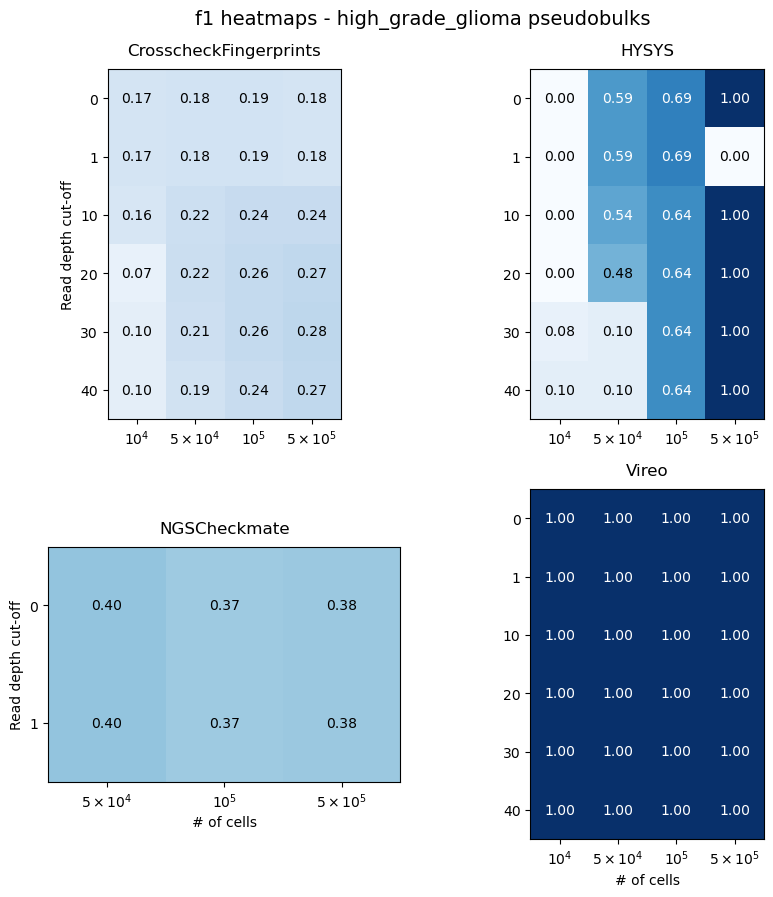

In [ ]:
# Visualize the accuracy metrics just calculated
heatmap_plot_accuracy_metrics_uneven_pseudobulk(
        df=full_df, 
        dataset="high_grade_glioma", 
        metric="f1",  # options: "fraction_inconclusive", "f1", "precision", "recall", "accuracy", "balanced_accuracy"
        save_fig=False, 
        FIGURES_PATH=FIGURES_PATH,
)

## Heatmap grid

Processing tool Vireo, dataset high_grade_glioma, read depth 0...
Processing tool Vireo, dataset high_grade_glioma, read depth 1...
Processing tool Vireo, dataset high_grade_glioma, read depth 10...
Processing tool Vireo, dataset high_grade_glioma, read depth 20...
Processing tool Vireo, dataset high_grade_glioma, read depth 30...
Processing tool Vireo, dataset high_grade_glioma, read depth 40...
Processing tool Vireo, dataset high_grade_glioma, read depth 0...
Processing tool Vireo, dataset high_grade_glioma, read depth 1...
Processing tool Vireo, dataset high_grade_glioma, read depth 10...
Processing tool Vireo, dataset high_grade_glioma, read depth 20...
Processing tool Vireo, dataset high_grade_glioma, read depth 30...
Processing tool Vireo, dataset high_grade_glioma, read depth 40...
Processing tool Vireo, dataset high_grade_glioma, read depth 0...
Processing tool Vireo, dataset high_grade_glioma, read depth 1...
Processing tool Vireo, dataset high_grade_glioma, read depth 10...
P

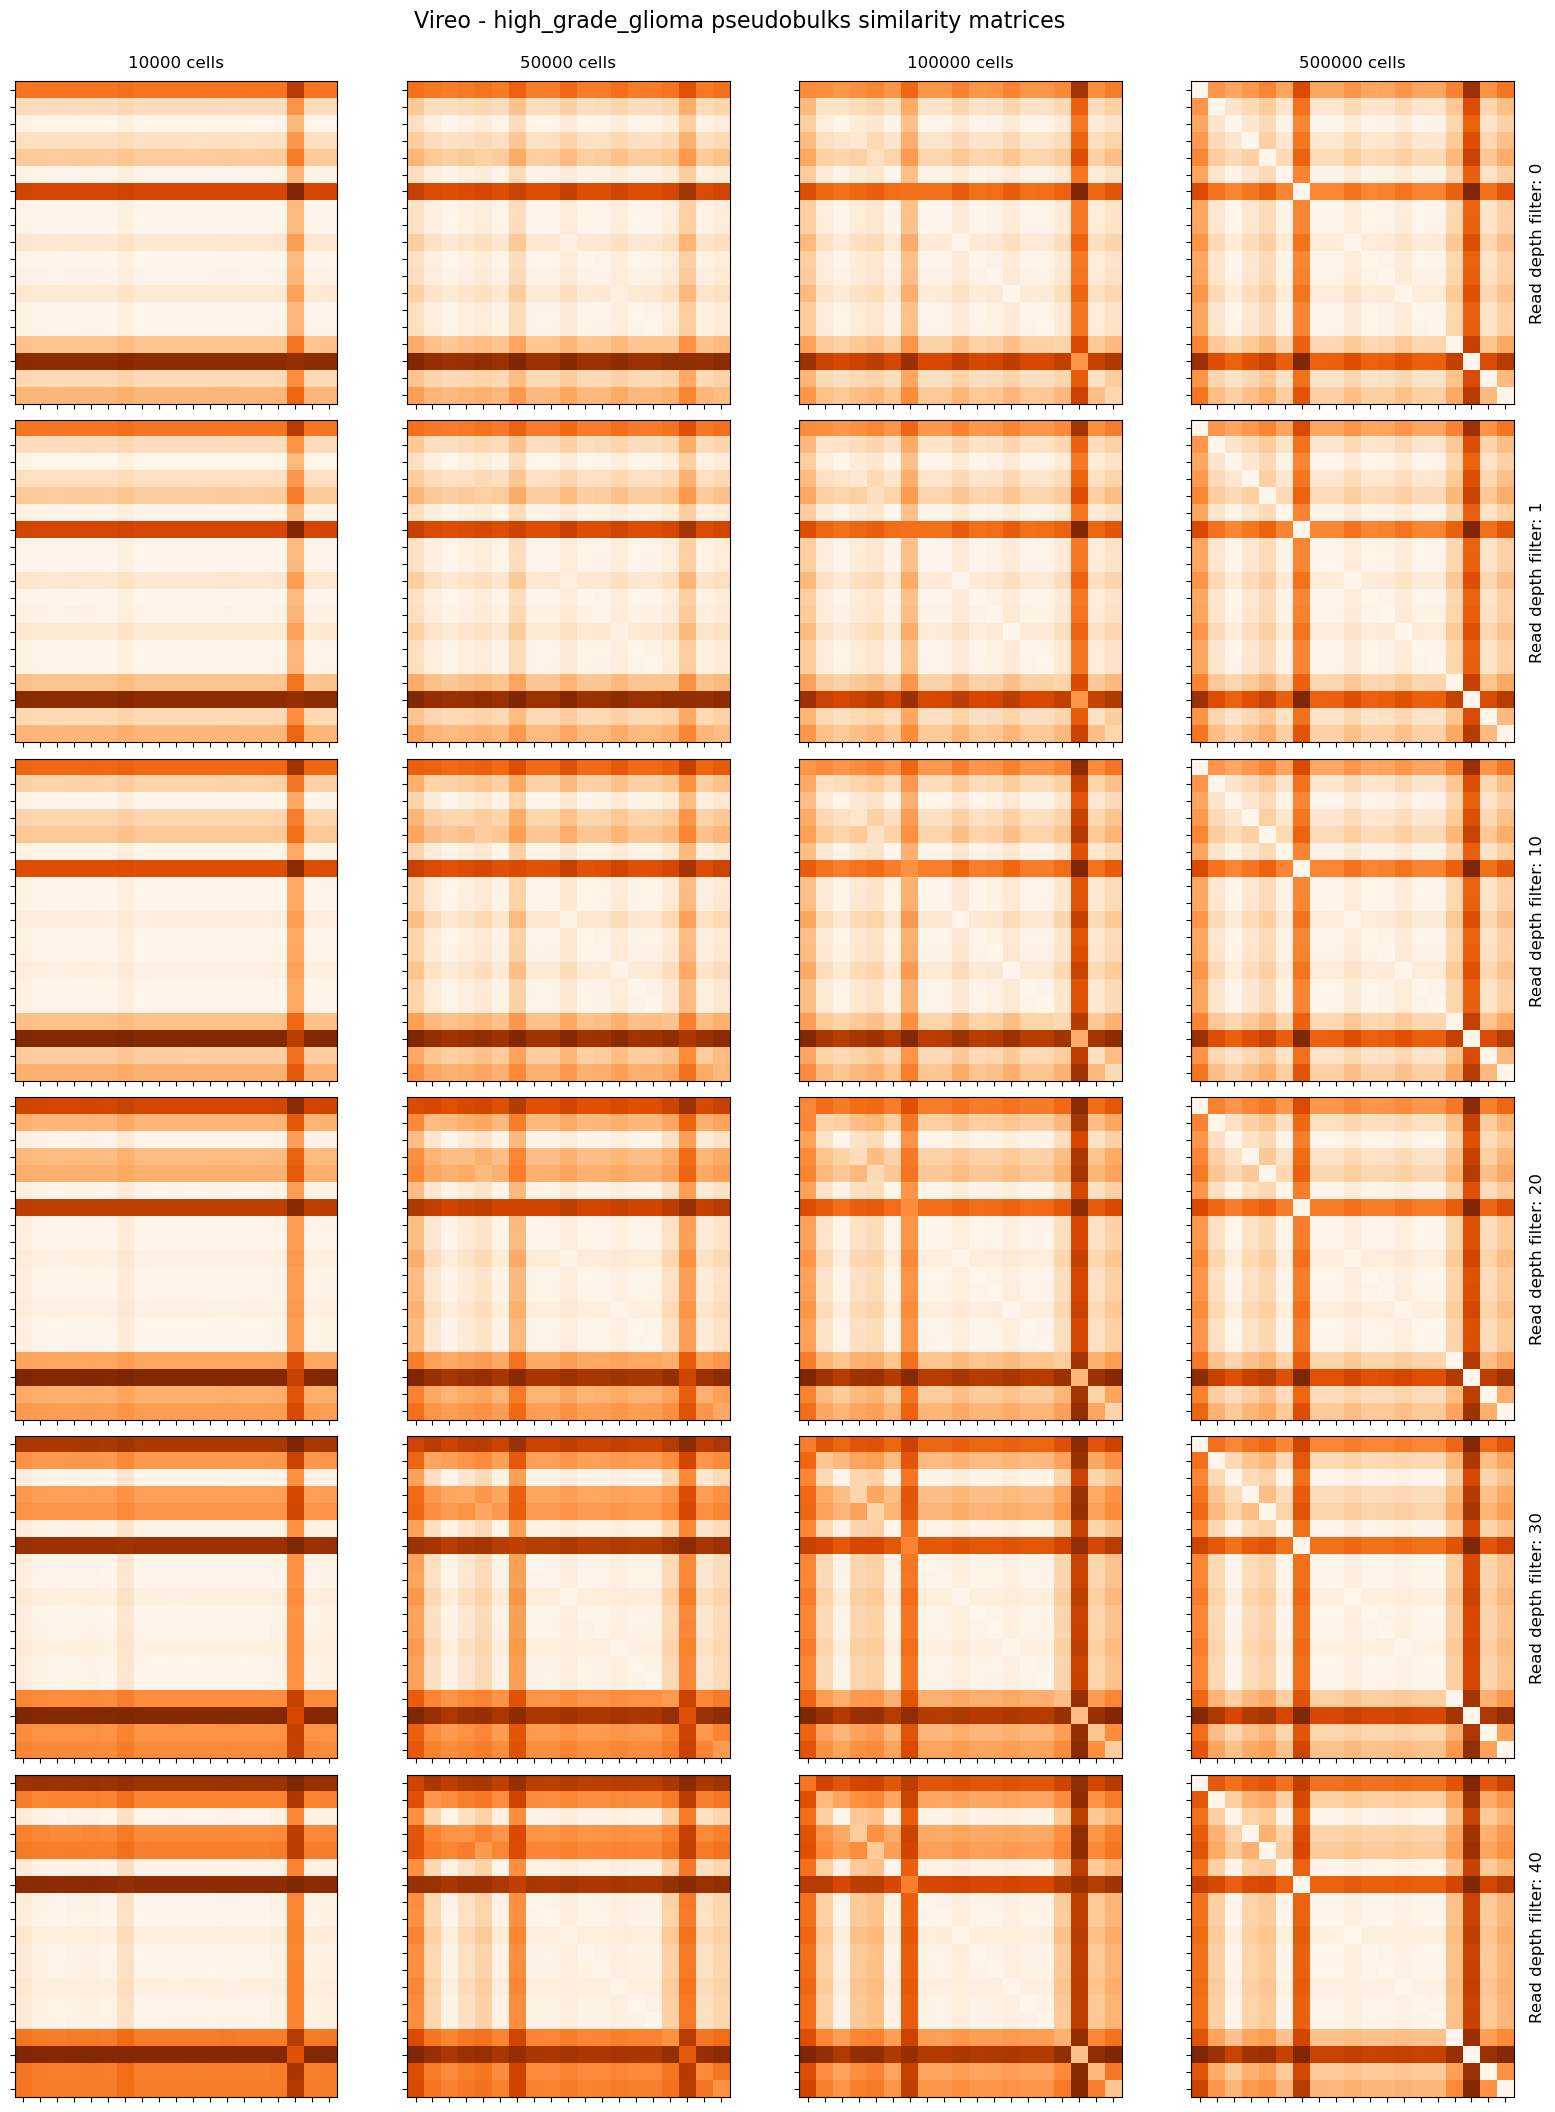

In [ ]:
# Visualize the heatmaps with different pseudobulk sizes
# The tool can be changed to visualize the heatmaps for different tools
super_plot_heatmaps_uneven_pseudobulk(
    DATA_PATH=DATA_PATH,
    FIGURES_PATH=FIGURES_PATH, 
    tool="Vireo", 
    dataset="high_grade_glioma", 
    ncells_1=500000,
    ncells_2_list=ncells_list, 
    read_depths=read_depths, 
    save_fig=False
)

# Pseudobulk vs single-cell

In [ ]:
# Calculate accuracy metrics for the pseudobulk vs single cell experiment for each tool, dataset, and read depth
df = loop_accuracy_calculations(
    DATA_PATH=DATA_PATH + f"pseudobulk_vs_sc/",
    experiment="pseudobulk_vs_sc",
    tools=tools,
    datasets=["high_grade_glioma"],
    ncells_list=[500000],
    read_depths=read_depths,
)
df.head()

Could not find data for NGSCheckmate, pseudobulk dataset high_grade_glioma, ncells 500000, read depth 10. 
Could not find data for NGSCheckmate, pseudobulk dataset high_grade_glioma, ncells 500000, read depth 20. 
Could not find data for NGSCheckmate, pseudobulk dataset high_grade_glioma, ncells 500000, read depth 30. 
Could not find data for NGSCheckmate, pseudobulk dataset high_grade_glioma, ncells 500000, read depth 40. 


,tool,pseudobulk,dataset,ncells,read depth,fraction_inconclusive,accuracy,balanced_accuracy,precision,recall,f1
0,CrosscheckFingerprints,True,high_grade_glioma,500000,0,0.252078,0.501385,0.711988,0.091371,0.947368,0.166667
1,CrosscheckFingerprints,True,high_grade_glioma,500000,1,0.252078,0.501385,0.711988,0.091371,0.947368,0.166667
2,CrosscheckFingerprints,True,high_grade_glioma,500000,10,0.437673,0.700831,0.742690,0.126050,0.789474,0.217391
3,CrosscheckFingerprints,True,high_grade_glioma,500000,20,0.595568,0.750693,0.744152,0.141414,0.736842,0.237288
4,CrosscheckFingerprints,True,high_grade_glioma,500000,30,0.642659,0.759003,0.748538,0.145833,0.736842,0.243478


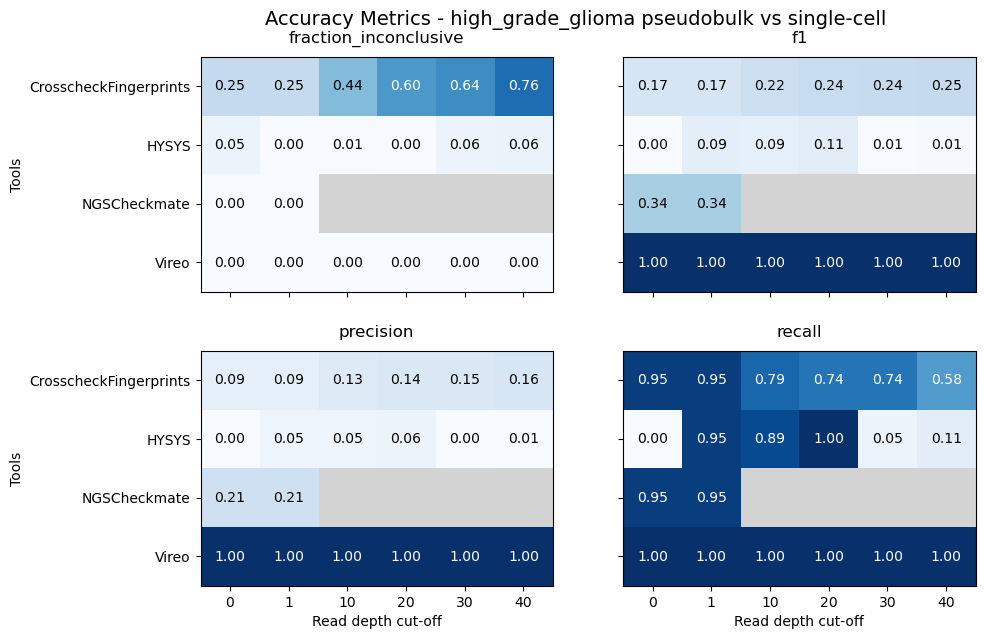

In [ ]:
# Visualize the accuracy metrics for the pseudobulk vs single cell experiment
heatmap_plot_accuracy_metrics_pseudobulk_vs_sc(
    df, 
    "high_grade_glioma", 
    ["fraction_inconclusive", "f1", "precision", "recall"], 
    save_fig=False, 
    FIGURES_PATH=FIGURES_PATH
)

Processing tool Vireo, dataset high_grade_glioma, read depth 0...
Processing tool Vireo, dataset high_grade_glioma, read depth 1...
Processing tool Vireo, dataset high_grade_glioma, read depth 10...
Processing tool Vireo, dataset high_grade_glioma, read depth 20...
Processing tool Vireo, dataset high_grade_glioma, read depth 30...
Processing tool Vireo, dataset high_grade_glioma, read depth 40...


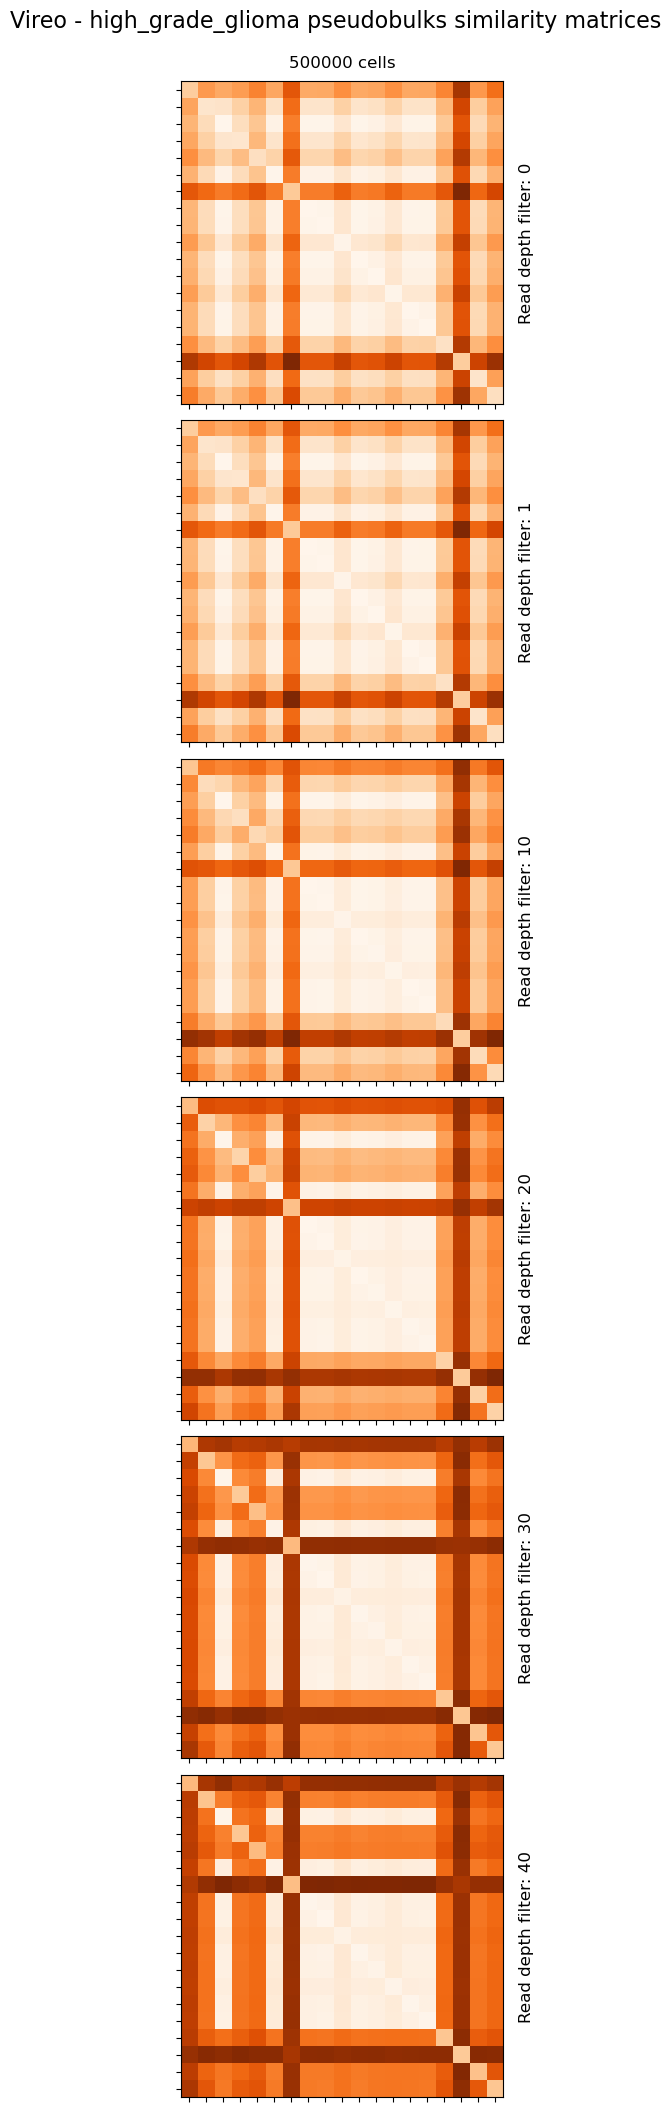

In [ ]:
# Visualize the heatmaps for the pseudobulk vs single cell experiment
# The tool can be changed to visualize the heatmaps for different tools
super_plot_heatmaps_pseudobulk(
    DATA_PATH=DATA_PATH + "pseudobulk_vs_sc/", 
    FIGURES_PATH=FIGURES_PATH, 
    tool="Vireo", 
    dataset="high_grade_glioma", 
    ncells_list=[500000], 
    read_depths=read_depths,
    experiment="pseudobulk_vs_sc",
    save_fig=False
)

# HYSYS heatmap, Vireo algorithm

In [ ]:
# Calculate accuracy metrics using the HYSYS sample similarity matrix and the Vireo algorithm
full_df = pd.DataFrame()
for ncells in ncells_list:
    df = accuracy_metrics_hysys_heatmap_vireo_algorithm(
        DATA_PATH=DATA_PATH,
        dataset="high_grade_glioma",
        ncells=ncells,
        rd=0,
    )
    full_df = pd.concat([full_df, df], ignore_index=True)

In [27]:
# Compare to regular experiments to see difference in performance with HYSYS and Vireo
df = loop_accuracy_calculations(
    DATA_PATH=DATA_PATH,
    experiment="basic",
    tools=["HYSYS", "Vireo"],
    datasets=["high_grade_glioma"],
    ncells_list=ncells_list,
    read_depths=[0],
)
full_df = pd.concat([full_df, df], ignore_index=True)


/Users/lathouwe/miniconda3/envs/analysis/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [28]:
full_df

,tool,pseudobulk,dataset,ncells,read depth,fraction_inconclusive,accuracy,balanced_accuracy,precision,recall,f1
0,"HYSYS matrix, Vireo algorithm",True,high_grade_glioma,10000,0,0.000000,0.988920,0.944444,0.894737,0.894737,0.894737
1,"HYSYS matrix, Vireo algorithm",True,high_grade_glioma,50000,0,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,"HYSYS matrix, Vireo algorithm",True,high_grade_glioma,100000,0,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,"HYSYS matrix, Vireo algorithm",True,high_grade_glioma,500000,0,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,HYSYS,True,high_grade_glioma,10000,0,0.038781,0.947368,0.500000,0.000000,0.000000,0.000000
5,HYSYS,True,high_grade_glioma,50000,0,0.000000,0.052632,0.500000,0.052632,1.000000,0.100000
6,HYSYS,True,high_grade_glioma,100000,0,0.027701,0.972299,0.736842,1.000000,0.473684,0.642857
7,HYSYS,True,high_grade_glioma,500000,0,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
8,Vireo,True,high_grade_glioma,10000,0,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
9,Vireo,True,high_grade_glioma,50000,0,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000


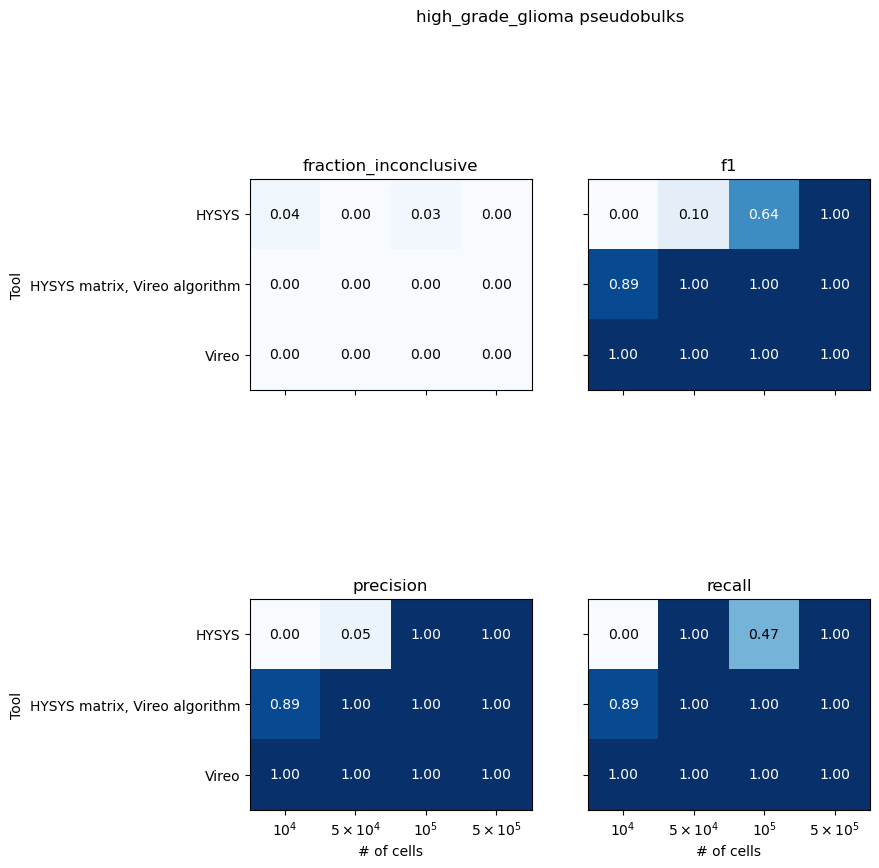

In [ ]:

# Visualize the accuracy metrics for the HYSYS heatmap, Vireo algorithm experiment + comparison to regular experiments
heatmap_plot_accuracy_metrics_pseudobulk_rd0(
    df=full_df, 
    dataset="high_grade_glioma", 
    save_fig=False, 
    FIGURES_PATH=FIGURES_PATH
)